### Experiment Notebook ###
This is the main entry point to run experiments. You can run this notebook to train a model and evaluate it on the test set. You can also modify the code here to run different experiments, such as changing the model architecture, training hyperparameters, or dataset.

This Notebook is designed to be runable from a local file system or on Google Colab. 
Colab is an appealing option because of the availability of GPU acellerators, but the code is designed to be runable on a local machine as well.
In order to run this in a colab, uncomment the first code cell and run it once to install the necessary dependencies. After that, you can run the rest of the notebook as usual.

**NOTE**: Run the following cell only if running from a google Colab notebook. It will install the required dependencies and set up the environment for running the experiments.


In [19]:
"""
%cd /content/drive/MyDrive

import os

if not os.path.exists("REAN"):
    !git clone https://github.com/steinburglar/REAN
else:
    %cd REAN
    !git pull

%cd /content/drive/MyDrive/REAN/notebooks
"""

'\n%cd /content/drive/MyDrive\n\nimport os\n\nif not os.path.exists("REAN"):\n    !git clone https://github.com/steinburglar/REAN\nelse:\n    %cd REAN\n    !git pull\n\n%cd /content/drive/MyDrive/REAN/notebooks\n'

First, we do some setup to move into the repository root and import the necessary modules.

In [ ]:

from pathlib import Path
import os
import sys

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    markers = ("pyproject.toml", ".git")
    for p in [start, *start.parents]:
        if any((p / m).exists() for m in markers):
            return p
    raise RuntimeError(f"Could not find repo root from {start}")

start = Path("/home/stein/classes/REAN/notebooks") #replace with the path to your notebooks directory on your machine

REPO_ROOT = find_repo_root(start)
DATA_DIR = REPO_ROOT / "datasets"
EXPERIMENTS_DIR = REPO_ROOT / "experiments"

print("Repo root:", REPO_ROOT)


from pathlib import Path

import torch
import json
import torch.nn as nn
from rean.utils.utils import make_run_dir, to_serializable
from rean.data.Dataset import make_datasets
from rean.training.train import train_full, evaluate
from rean.utils.plot import LossPlot
import matplotlib.pyplot as plt

Repo root: /home/stein/classes/REAN


Next, we set some hyperparameters for the experiement. You can modify these to run different experiments. 
Note that these hyperparameters will not be modified in one experimental "sweep", unlike experiemental parameters like std or noiseType (see below)

**Developers note** -it would be good to refactor the code so that these hyperparameters are stored and passed as a dictionary to the training and evaluation functions, rather than being set as global variables.
Then they can easily be logged in a json of metasdata for each run.

In [ ]:
#Hyperparameters. They should be consistent across any single experiement.
#NOTE: These are params for the Plain CNN model.
# They are scaled down for the other models to ensure a fair comparison

group_order = 4
hidden_dim = 4
out_channels = hidden_dim
classes = 10
kernel_size = 3
num_gconvs = 2
num_epochs = 2
batch_size = 64
learning_rate = 0.002
gamma = 2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Path to save experiment results. subsitute with your desired name
exp_path = EXPERIMENTS_DIR / "test_experiment_03_02_2026"

# Experiment Running Loop #

This cell will run one "experiement", which consists of a single sweep over model types and noise parameters at a fixed set of training hyperparameters. You can modify the code here to change what parameters you sweep over, but hyperparameters should changed above.

Note that in order to provide a fair comparison, the equivariant models have hyperparameter multipliers that scale down their number of channels to give all models roughly equivalent number of parameters. this happens automatically, and you should in general NOT change how hyperparameters are passed to the models.

In [ ]:
#test full loop
models = ['PlainCNN', 'P4CNN', 'RelaxedP4CNN']
noise_types = ['none', 'iso', 'aniso']
stds = [0.1, 0.2, 0.3]

for model_name in models:
    for noise_type in noise_types:
        for i, std in enumerate(stds):
            if noise_type == 'none':
                if i != 0: #only run noiseless once
                    continue
                train_noise = None
                test_noise = None
                noise_params = {"mean":0, "std":0, 'gamma':0}

            else:
                train_noise = noise_type
                test_noise = noise_type #could be none?
                noise_params = {'mean': 0, 'std': std, 'gamma': gamma}
            
            #make datasets
            train_ds, val_ds, test_ds_noised, in_channels = make_datasets(
                train_noise=train_noise,
                test_noise = test_noise,
                noise_params=noise_params,
                group_order=group_order,
                root = DATA_DIR)
            
            #TO DO: collapse this s.t. make_datasets returns test clean always
            _, _, test_ds_clean, _ = make_datasets(
                    test_noise=None,
                    noise_params=noise_params,
                    group_order=group_order,
                    root = DATA_DIR)
            #train model
            run_data, best_model = train_full(
                                model_name=model_name,
                                train_ds=train_ds,
                                val_ds=val_ds,
                                in_channels=in_channels,
                                hidden_dim=hidden_dim,
                                out_channels=out_channels,
                                classes=classes,
                                num_gconvs=num_gconvs,
                                kernel_size=kernel_size,
                                group_order=group_order,
                                num_epochs=num_epochs,
                                batch_size=batch_size,
                                learning_rate=learning_rate,
                                device=device)
            
            run_data['noise_type'] = noise_type #Perhaps train_full should return this info instead of having to pass it in?
            run_data['std'] = std

            run_dir = make_run_dir(
                    model_name,
                    noise_type,
                    noise_params = noise_params,
                    learning_rate = learning_rate,
                    experiment = exp_path)
            
            torch.save(best_model.state_dict(), run_dir/"model.pt")
            with open(run_dir / "run_data.json", "w") as f:
                json.dump(run_data, f, default = to_serializable, indent=2)

            #test the model
            test_noisy_loader = torch.utils.data.DataLoader(test_ds_noised, 
                                                            batch_size=batch_size,
                                                            shuffle=False,
                                                            pin_memory =True)
            
            #To do: clean up this logic to make simpler. Perhaps just collapse with a hidden utils function?            
            test_clean_loader = torch.utils.data.DataLoader(test_ds_clean,batch_size=batch_size, shuffle=False, pin_memory =True)
            
            criterion = nn.CrossEntropyLoss()
            test_loss, test_acc = evaluate(best_model,  device, test_noisy_loader, criterion = criterion)
            test_loss_clean, test_acc_clean = evaluate(best_model,
                                                       device,
                                                       test_clean_loader,
                                                       criterion = criterion)
            test = {
                "test_noisy_loss": test_loss,
                "test__noisy_acc": test_acc,
                "test_clean_loss": test_loss_clean,
                "test_clean_acc": test_acc_clean
            }
            print(f"Test Loss: {test_loss}, Test Acc: {test_acc}")
            with open(run_dir / "test_data.json", "w") as f:
                json.dump(test, f, default = to_serializable, indent=2)



Epoch 1/2, Train Loss: 2.0810, Val Loss: 1.8495, Val Acc: 29.38%
Epoch 2/2, Train Loss: 1.8168, Val Loss: 1.7903, Val Acc: 32.80%
Test Loss: 1.7777359811782838, Test Acc: 32.79
Epoch 1/2, Train Loss: 2.0982, Val Loss: 1.9967, Val Acc: 25.53%
Epoch 2/2, Train Loss: 1.9902, Val Loss: 1.9786, Val Acc: 25.53%
Test Loss: 1.9737337812423705, Test Acc: 24.6
Epoch 1/2, Train Loss: 2.0522, Val Loss: 1.9234, Val Acc: 27.87%
Epoch 2/2, Train Loss: 1.8708, Val Loss: 1.8345, Val Acc: 31.05%
Test Loss: 1.817648080444336, Test Acc: 30.62
Epoch 1/2, Train Loss: 2.2959, Val Loss: 2.2730, Val Acc: 11.71%
Epoch 2/2, Train Loss: 2.2339, Val Loss: 2.1673, Val Acc: 22.12%
Test Loss: 2.16572480430603, Test Acc: 22.79
Epoch 1/2, Train Loss: 2.0269, Val Loss: 1.8335, Val Acc: 30.32%
Epoch 2/2, Train Loss: 1.8273, Val Loss: 1.8197, Val Acc: 30.68%
Test Loss: 1.799339323425293, Test Acc: 30.9
Epoch 1/2, Train Loss: 2.0583, Val Loss: 1.9772, Val Acc: 26.42%
Epoch 2/2, Train Loss: 1.9289, Val Loss: 1.8678, Val Acc

# Plotting #
The following cells generate plots of training and validation loss, as well as a csv of test losses.

**Developer Note** - the plotting code could use some substantial refactoring, as it was built with a rush to generate plots. Since the data is all on disk already at this point, all the plotting needs as input is the paths to the run files, as well as the parameters to label the plots, which can easily be packaged as a dictionary and handed to a plotting class that manages all of this.

Additionally, the runs should start to store their hyperparameters and noise parameters as a dictionary (json) in their particualr run dir, so that the information is not lost and can be easily accessed for plotting and analysis. This is especially important as the number of runs grows, and it becomes difficult to keep track of which run corresponds to which parameters.

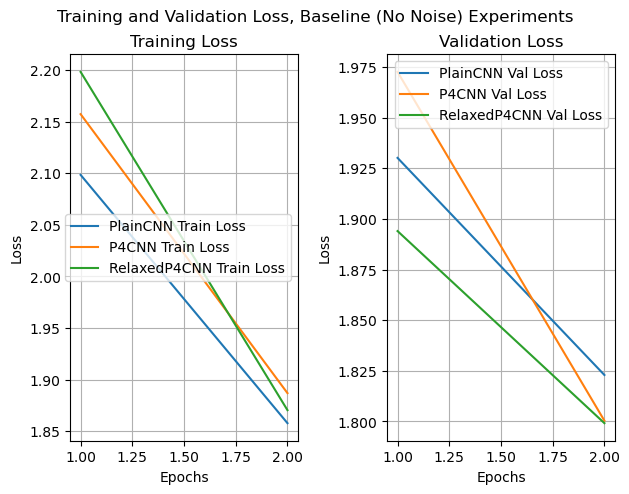

: 

In [ ]:
#add experiments to path

sys.path.append(str(exp_path))

plot_path = exp_path / "plots"
plot_path.mkdir(exist_ok=True)

#first, plot the performance of all 3 models on the baseline noisesless test set, on two sets of axes: one for train, one for validation
fig, (train_ax, val_ax) = plt.subplots(1,2)
runs = []
tests = []

for model_name in models:
    runpath = exp_path / "runs" / f"{model_name}_none_std0_gamma0_lr{learning_rate}"

    #load the rundata in from the json
    rundatapath = runpath / "run_data.json"
    testdatapath = runpath / "test_data.json"
    with rundatapath.open("r", encoding="utf-8") as f:
        run_data = json.load(f)
    with testdatapath.open("r", encoding="utf-8") as f:
        test_data = json.load(f)
    run_data.update(test_data)
    runs.append(run_data)
    tests.append(test_data)

#make loss plots
train_ax = LossPlot(train_ax, runs, labels = ["model_name"], title = "Training Loss", val = False)
val_ax = LossPlot(val_ax, runs, labels = ['model_name'], title = "Validation Loss", train = False)
fig.tight_layout()
fig.suptitle("Training and Validation Loss, Baseline (No Noise) Experiments", y=1.02)
fig.savefig(plot_path / "baseline_loss_plots.png")







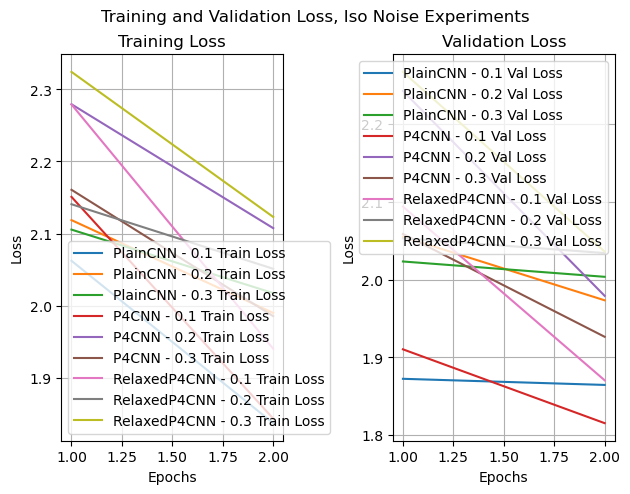

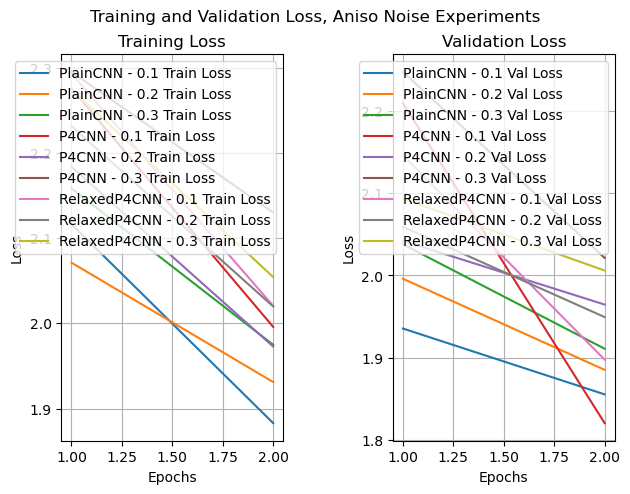

: 

In [ ]:
# do the same for each noise type, but plotting both std runs on the same axes
#so, each axes object will have 6 lines: 3 models x 2 stds
noise_types = ['iso', 'aniso']
for noise_type in noise_types:
    fig, (train_ax, val_ax) = plt.subplots(1,2)
    runs = []
    tests = []
    for model_name in models:
        for std in stds:
            runpath = exp_path / f"runs/{model_name}_{noise_type}_std{std}_gamma{gamma}_lr{learning_rate}"
            
            #load the rundata in from the json
            rundatapath = runpath / "run_data.json"
            testdatapath = runpath / "test_data.json"
            with rundatapath.open("r", encoding="utf-8") as f:
                run_data = json.load(f)
            with testdatapath.open("r", encoding="utf-8") as f:
                test_data = json.load(f)
            run_data.update(test_data)
            runs.append(run_data)
            tests.append(test_data)

    #make loss plots
    train_ax = LossPlot(train_ax, runs, labels = ["model_name", "std"], title = "Training Loss", val = False)
    val_ax = LossPlot(val_ax, runs, labels = ['model_name', "std"], title = "Validation Loss", train = False)
    fig.tight_layout()
    fig.suptitle(f"Training and Validation Loss, {noise_type.capitalize()} Noise Experiments", y=1.02)
    fig.savefig(plot_path / f"{noise_type}_loss_plots.png")


In [ ]:
#fianlly, generate a dataframe for test accuracies across all runs
import pandas as pd
all_runs = []
for model_name in models:
    for noise_type in noise_types + ['none']:
        for std in stds:
            if noise_type == 'none':
                runpath = exp_path /f"runs/{model_name}_none_std0_gamma0_lr{learning_rate}"
                std = 0
            else:
                runpath = exp_path / f"runs/{model_name}_{noise_type}_std{std}_gamma{gamma}_lr{learning_rate}"
            #load the rundata in from the json
            rundatapath = runpath / "run_data.json"
            testdatapath = runpath / "test_data.json"
            with rundatapath.open("r", encoding="utf-8") as f:
                run_data = json.load(f)
            with testdatapath.open("r", encoding="utf-8") as f:
                test_data = json.load(f)
            run_data.update(test_data)
            all_runs.append(run_data)
df = pd.DataFrame(all_runs)
df = df[['model_name', 'noise_type', 'std', 'test__noisy_acc', "test_clean_acc"]] #get only the stuff we want
df.to_csv(plot_path / "test_accuracies.csv", index=False)

: 